In [ ]:
!pip install xgboost

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle competitions download -c quora-question-pairs

100% 309M/309M [00:05<00:00, 100MB/s]
100% 309M/309M [00:05<00:00, 62.9MB/s]


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/train.csv.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import pandas as pd
df_train=pd.read_csv("/content/train.csv")
df_train.head(100)


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0
...,...,...,...,...,...,...
95,95,191,192,How does 3D printing work?,How do 3D printing work?,1
96,96,193,194,What was it like to attend Caltech with Jeremy...,Who are some notable folks who attended Caltech?,0
97,97,195,196,Why did harry become a horcrux?,What is a Horcrux?,0
98,98,197,198,What are the best associate product manager (A...,What are the general requirement to become a P...,0


In [ ]:
df_train.info()
print(df_train.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB
            id    qid1    qid2  \
404285  404285  433578  379845   
404286  404286   18840  155606   
404287  404287  537928  537929   
404288  404288  537930  537931   
404289  404289  537932  537933   

                                                question1  \
404285  How many keywords are there in the Racket prog...   
404286          Do you believe there is life after death?   
404287                                  What is one coin?   
404288  What is the approx annual cost of livi

In [ ]:
df_train.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,1
question2,2
is_duplicate,0


is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
0    63.0
1    37.0
Name: count, dtype: float64


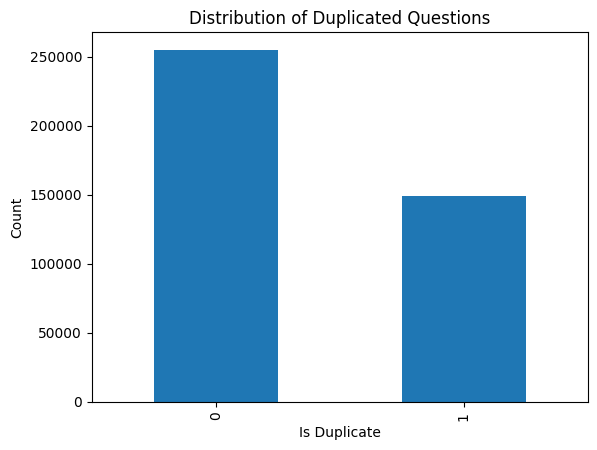

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Print value counts for duplicated questions
print(df_train['is_duplicate'].value_counts())

# Calculate percentage of duplicated questions
percentage_duplicated = (df_train['is_duplicate'].value_counts() / df_train['is_duplicate'].count()) * 100
print(round(percentage_duplicated))

# Create a bar plot
df_train['is_duplicate'].value_counts().plot(kind='bar')
plt.xlabel("Is Duplicate")
plt.ylabel("Count")
plt.title("Distribution of Duplicated Questions")
plt.show()



In [ ]:
print(df_train.duplicated().sum())

0


In [ ]:
#Rpeated Questions
import numpy as np
qid=pd.Series(df_train['qid1'].tolist() + df_train['qid2'].tolist())
print("There are {} unique questions".format(np.unique(qid).shape[0]))
x=qid.value_counts()>1
print('Number of questions are getting repeated', x[x].shape[0])

There are 537933 unique questions
Number of questions are getting repeated 111780


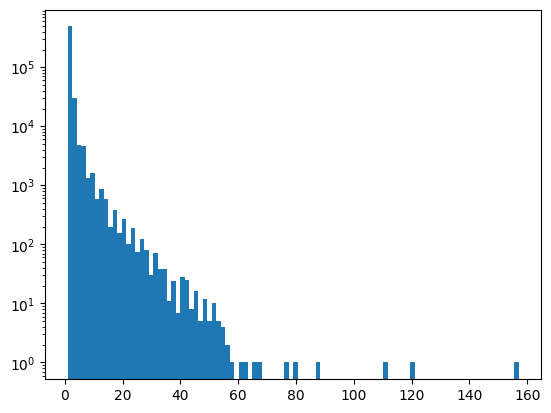

In [ ]:
plt.hist(qid.value_counts().values, bins=100)
plt.yscale('log')
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd

# Sample the data
new_train = df_train[['question1', 'question2']].sample(20000, random_state=42)
# Get the indices of the sampled rows
sampled_indices = new_train.index

# Create a new DataFrame excluding the sampled rows
remaining_data = df_train.drop(sampled_indices).drop_duplicates().sample(10000, random_state=42)

class QuestionProcessor:
    def __init__(self, max_features=1000):
        self.cv = CountVectorizer(max_features=max_features)

    def fit(self, dataframe):
        questions = list(dataframe['question1'].fillna('')) + list(dataframe['question2'].fillna(''))
        self.cv.fit(questions)

    def transform(self, dataframe):
        q1_questions = dataframe['question1'].fillna('')
        q2_questions = dataframe['question2'].fillna('')
        q1_array = self.cv.transform(q1_questions).toarray()
        q2_array = self.cv.transform(q2_questions).toarray()
        return q1_array, q2_array

# Create an instance of QuestionProcessor and fit on new_train
processor = QuestionProcessor()
processor.fit(new_train)

# Transform new_train, new_test, and remaining_data
q1_train, q2_train = processor.transform(new_train)
q1_test, q2_test = processor.transform(new_test)

# Optional: Display the first few rows of the processed arrays for verification
print("First few rows of q1_train:")
print(q1_train[:5])
print("First few rows of q2_train:")
print(q2_train[:5])

print("First few rows of q1_remaining:")
print(q1_remaining[:5])
print("First few rows of q2_remaining:")
print(q2_remaining[:5])


First few rows of q1_train:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
First few rows of q2_train:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
First few rows of q1_remaining:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
First few rows of q2_remaining:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
# Transform new_train
q1_train, q2_train = processor.transform(new_train)
temp_df_train1 = pd.DataFrame(q1_train, index=new_train.index)
temp_df_train2 = pd.DataFrame(q2_train, index=new_train.index)
temp_df_train = pd.concat((temp_df_train1, temp_df_train2), axis=1)

# Transform remaining_data
q1_remaining, q2_remaining = processor.transform(remaining_data)
temp_df_remaining1 = pd.DataFrame(q1_remaining, index=remaining_data.index)
temp_df_remaining2 = pd.DataFrame(q2_remaining, index=remaining_data.index)
temp_df_remaining = pd.concat((temp_df_remaining1, temp_df_remaining2), axis=1)

# Optional: Display the first few rows of the processed arrays for verification
print("First few rows of temp_df_train:")
print(temp_df_train.head())

print("First few rows of temp_df_remaining:")
print(temp_df_remaining.head())

First few rows of temp_df_train:
        0    1    2    3    4    5    6    7    8    9    ...  990  991  992  \
8067      0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
368101    0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
70497     0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
226567    0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
73186     0    0    0    0    0    0    0    0    0    0  ...    0    0    0   

        993  994  995  996  997  998  999  
8067      0    0    0    0    0    0    0  
368101    0    0    0    0    0    0    0  
70497     0    0    0    0    0    0    0  
226567    0    0    0    0    0    0    0  
73186     0    0    0    0    0    0    0  

[5 rows x 2000 columns]
First few rows of temp_df_remaining:
        0    1    2    3    4    5    6    7    8    9    ...  990  991  992  \
237655    0    0    0    0    0    0    0    0    0    0  ...    0    0    0   


In [ ]:
# Filter 'is_duplicate' column for new_train and add it to temp_df_train
filtered_is_duplicate_train = df_train.loc[new_train.index, 'is_duplicate']
temp_df_train['is_duplicate'] = filtered_is_duplicate_train

# Display the first few rows of temp_df_train
print("First few rows of temp_df_train:")
print(temp_df_train.head(10))



First few rows of temp_df_train:
        0  1  2  3  4  5  6  7  8  9  ...  991  992  993  994  995  996  997  \
8067    0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
368101  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
70497   0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
226567  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
73186   0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
215105  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
253209  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
354651  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   
104478  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    1    1   
163628  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0   

        998  999  is_duplicate  
8067      0    0             0  
368101    0    0    

In [ ]:
remaining_data.shape

(10000, 6)

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier
import pandas as pd

# Apply pd.to_numeric to temp_df_train and temp_df_test
temp_df_train = temp_df_train.apply(pd.to_numeric)
temp_df_test = temp_df_test.apply(pd.to_numeric)
temp_df_remaining = temp_df_remaining.apply(pd.to_numeric)
# Assign full datasets to training and testing sets
X_train = temp_df_train.drop(columns=['is_duplicate'])
y_train = temp_df_train['is_duplicate']
y_test = remaining_data['is_duplicate']

X_train.columns = [f'feature_{i}' for i in range(len(X_train.columns))]
X_test=temp_df_remaining
# Create an XGBoost classifier
xgb = XGBClassifier()
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, scoring='accuracy', cv=3, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters: ", grid_search.best_params_)
print("Best Cross-validation Accuracy: ", grid_search.best_score_)


Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters:  {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best Cross-validation Accuracy:  0.6997498684921739


In [ ]:

X_test.columns = X_train.columns
# Convert y_test to binary labels (0 or 1)
y_test_binary = (y_test > 0.5).astype(int)

# Evaluate on test set using the best model found by GridSearchCV
test_accuracy = grid_search.score(X_test, y_test_binary)
print("Test Accuracy: ", test_accuracy)



Test Accuracy:  0.7063


In [ ]:
#Define base estimator (XGBoost classifier)
base_estimator = XGBClassifier(**grid_search.best_params_)

# Define bagging classifier
bagging_clf = BaggingClassifier(base_estimator=base_estimator, n_estimators=10, random_state=42)

# Train the bagging classifier
bagging_clf.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


BaggingClassifier(base_estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=1.0,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric=None,
                                               feature_types=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.1, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=5,
                                               max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=100, n_jobs=None,
                                               num_parallel_tree=None,
                                               random_state=None, ...),
                  random_state=42)

In [ ]:
# Convert y_test to binary labels (0 or 1)
y_test_binary = (y_test > 0.5).astype(int)

# Evaluate the bagging classifier on the test set
test_accuracy_bagging = bagging_clf.score(X_test, y_test_binary)
print("Test Accuracy (Bagging): ", test_accuracy_bagging)


Test Accuracy (Bagging):  0.7076


In [ ]:
import pickle

# Assuming 'bagging_clf' is your trained model
model_file_path = 'bagging_classifier_model.pkl'  # Specify the file path where you want to save the model

# Save the trained model to a file using pickle
with open(model_file_path, 'wb') as file:
    pickle.dump(bagging_clf, file)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pickle

# Assuming 'bagging_clf' is your trained model
model_file_path = '/content/drive/My Drive/bagging_classifier_model.pkl'  # Specify the file path in your Google Drive

# Save the trained model to a file using pickle
with open(model_file_path, 'wb') as file:
    pickle.dump(bagging_clf, file)
